In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from res import *

combined_mask : has schema Schema({'lod_level': UInt8, 'lod_code': String, 'face': String, 'i': UInt32, 'j': UInt32, 'row_id': UInt32}) and       additional information Parquet SCAN [C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33-Database-Refinement-Improved\data_products\combined_mask.parquet]
PROJECT */6 COLUMNS
ESTIMATED ROWS: 134519709
combined_atlas : has schema Schema({'face': String, 'i': UInt32, 'j': UInt32, 'uint8_reflectance': UInt8, '32bit_reflectance': Float32, 'positions_x': Float32, 'positions_y': Float32, 'positions_z': Float32}) and       additional information Parquet SCAN [C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33-Database-Refinement-Improved\data_products\combined_atlas.parquet]
PROJECT */8 COLUMNS
ESTIMATED ROWS: 402653184
mask_atlas_combined : has schema Schema({'lod_level': UInt8, 'lod_code': String, 'face': String, 'i': UInt32, 'j': UInt32, 'row_id': UInt32, 'uint8_reflectance': UInt8, '32bit_reflectance': Float32, 'positions_x'

In [2]:
# agg_data = boulder_agg_data.collect().filter(
#             pl.col("longest_axis_diameter") > 4)
        
# min_surface_area = agg_data["surface_area"].min()
# print(min_surface_area)

In [23]:
from statsmodels.base.model import GenericLikelihoodModel
from quick_calculate_vari_phis import FittingFunction

fit = FittingFunction(LAD_min=0.6)

class TheoryFit(GenericLikelihoodModel):
    param_names = ["g", "b"]

    def __init__(self, x):
        super().__init__(x)

    def loglikeobs(self, params):
        x = self.endog
        print(f"Ran iteration with params {params}")
        return np.log(fit.F_norm(x, 0.4354153058515187, 0.1 * params[0], 0, params[1]))

    @property
    def start_params(self):
        return np.array([1, -2.5])
    
mle_model = TheoryFit(fit.cleaned_data.collect()["alpha"].to_numpy()).fit()

Ran iteration with params [ 1.  -2.5]
Ran iteration with params [ 1.05 -2.5 ]
Ran iteration with params [ 1.    -2.625]
Ran iteration with params [ 1.05  -2.375]
Ran iteration with params [ 1.075 -2.25 ]
Ran iteration with params [ 1.125 -2.25 ]
Ran iteration with params [ 1.1875 -2.125 ]
Ran iteration with params [ 1.2125 -1.875 ]
Ran iteration with params [ 1.29375 -1.5625 ]
Ran iteration with params [ 1.40625 -1.4375 ]
Ran iteration with params [ 1.571875 -1.03125 ]
Ran iteration with params [ 1.5125 -0.875 ]
Ran iteration with params [ 1.26875 -1.8125 ]
Ran iteration with params [ 1.43125 -1.1875 ]
Ran iteration with params [ 1.309375 -1.65625 ]
Ran iteration with params [ 1.421875 -1.53125 ]
Ran iteration with params [ 1.4859375 -1.515625 ]
Ran iteration with params [ 1.325 -1.75 ]
Ran iteration with params [ 1.4375 -1.625 ]
Ran iteration with params [ 1.5015625 -1.609375 ]
Ran iteration with params [ 1.5984375 -1.390625 ]
Ran iteration with params [ 1.39335937 -1.66015625]
Ran it

In [28]:
print(mle_model.summary())
mle_model.model.loglikeobs(mle_model.params).mean()

                              TheoryFit Results                               
Dep. Variable:                      y   Log-Likelihood:            -1.2794e+06
Model:                      TheoryFit   AIC:                         2.559e+06
Method:            Maximum Likelihood   BIC:                         2.559e+06
Date:                Sat, 25 Apr 2026                                         
Time:                        16:32:11                                         
No. Observations:              182978                                         
Df Residuals:                  182976                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0           1.7108   3.48e-05   4.92e+04      0.000       1.711       1.711
par1          -2.1341      0.006   -350.688      0.0

np.float64(-6.992204945015756)

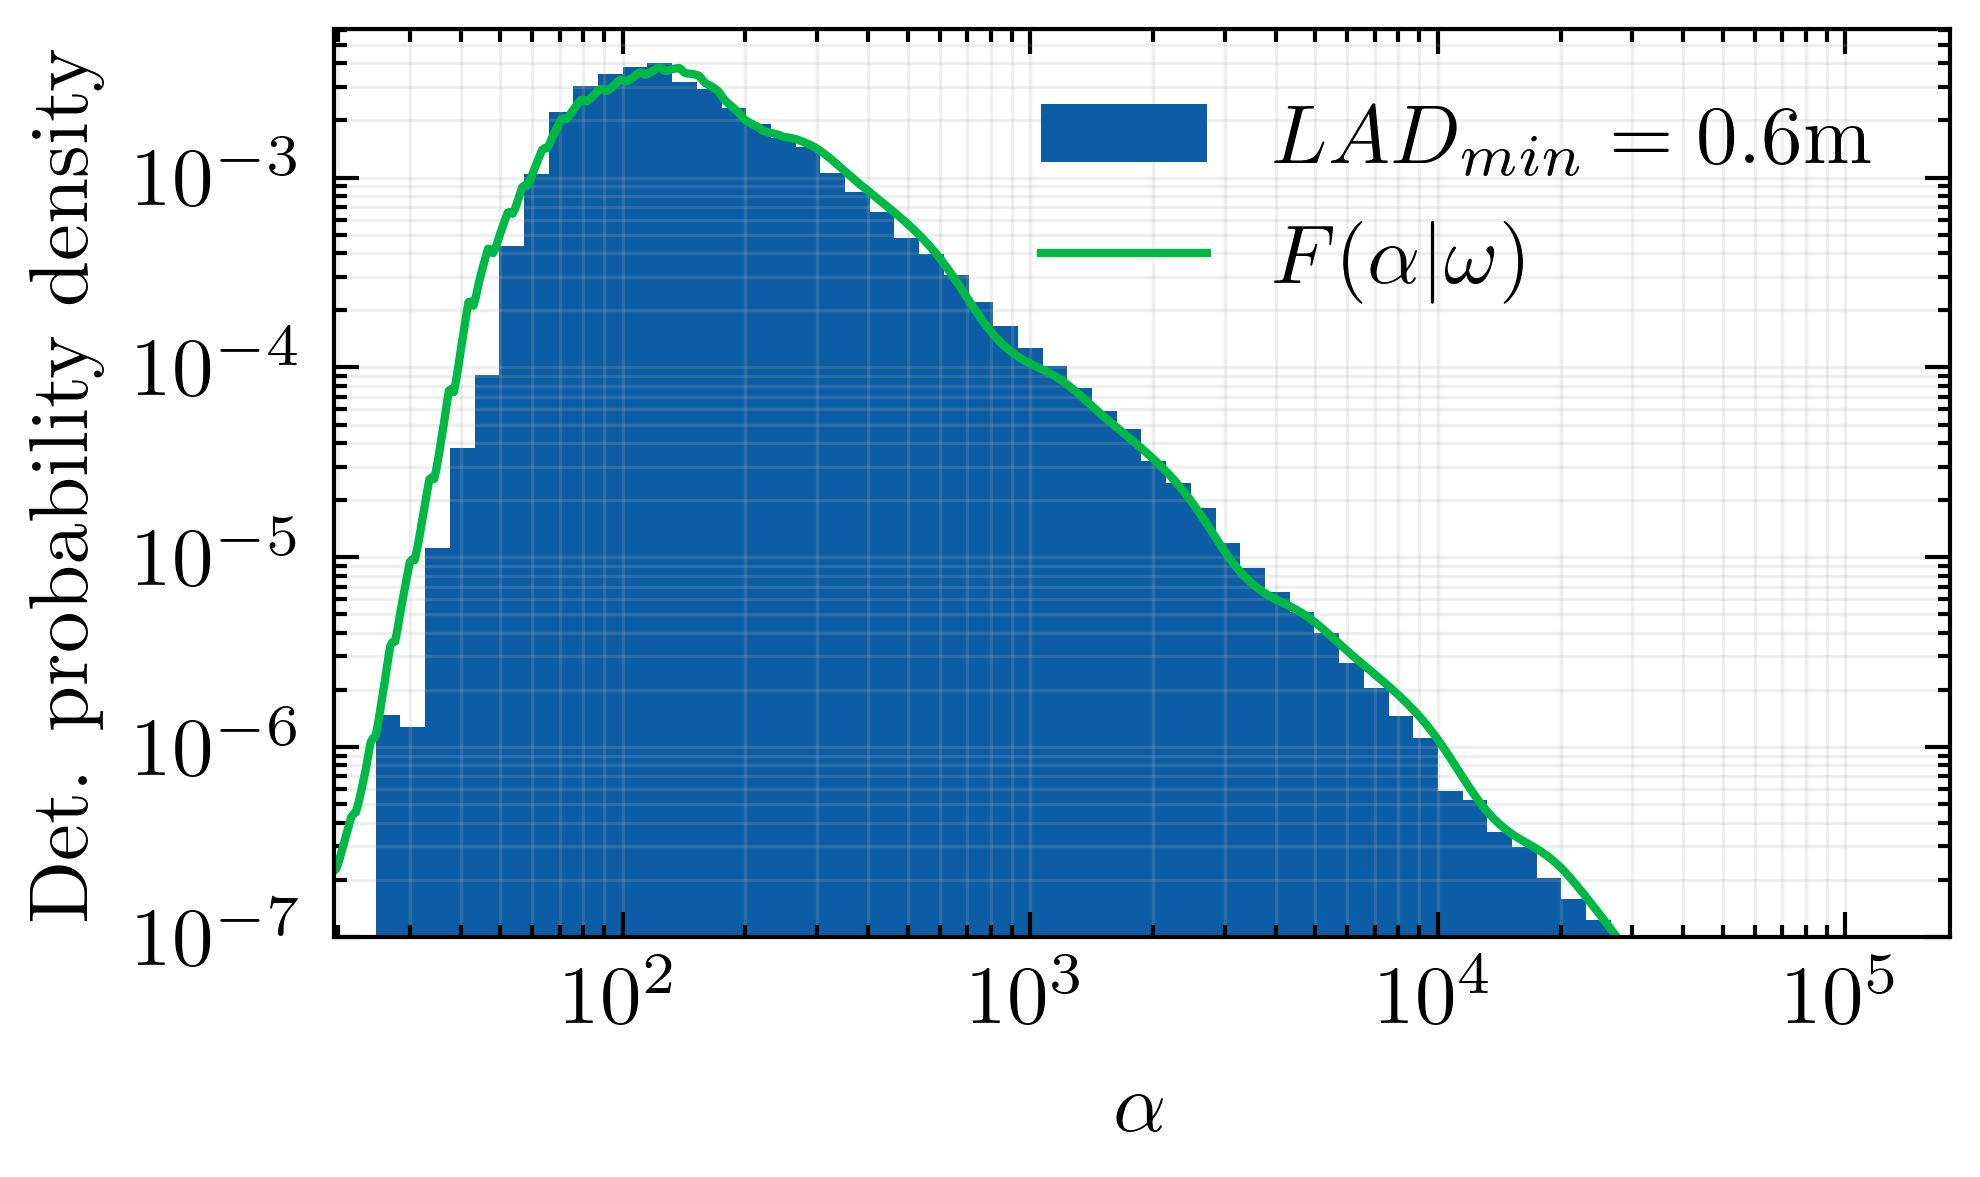

In [25]:
# 1.6290 0.6006 for LAD min = 2

alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True, label = rf"$LAD_{{min}} = {fit.LAD_min}$m")
# plt.plot(alphas, fit.F_norm(alphas, 0.4354153058515187, 0.1, 0, -2.5), label = r"$F(\alpha|\omega)$")

plt.plot(alphas, fit.F_norm(alphas, 0.4354153058515187,  0.1 * mle_model.params[0], 0, mle_model.params[1]), label = r"$F(\alpha|\omega)$")

plt.ylim(1e-7, counts.max() * 1.5)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("overall_fit.png")
plt.show()

In [26]:
def get_fit_summary_to_export(model):
    results = {}

    results["params"] = model.params
    results["BIC"] = model.bic
    results["AIC"] = model.aic
    results["pvalues"] = model.pvalues

    try:
        results["cov_params"] = model.cov_params()
    except ValueError:
        results["cov_params"] = np.nan

    return results

In [27]:
# plt.ioff()

# min_LAD = 0.3
# max_LAD = 3

# while True:
#     LAD_min_sample = np.exp(
#             np.random.uniform(np.log(min_LAD), np.log(max_LAD))
#         )

#     fit = FittingFunction(
#         LAD_min = LAD_min_sample
#         )

#     class TheoryFit(GenericLikelihoodModel):
#         param_names = ["phi", "b"]

#         def __init__(self, x):
#             super().__init__(x)

#         def loglikeobs(self, params):
#             x = self.endog
#             print(f"Ran iteration with params {params}")
#             return np.log(fit.F_norm(x, 0.4354153058515187, 0.1 * params[0], 0, params[1]))

#         @property
#         def start_params(self):
#             return np.array([1.3, -2.5])

#     mle_model = TheoryFit(fit.cleaned_data.collect()["alpha"].to_numpy()).fit()
    
#     results_stem = Path("results_jacobian") / f"LAD-{LAD_min_sample:.4f}".replace(".", "_")
#     results_stem.parent.mkdir(parents=True, exist_ok=True)

#     alphas_hist = np.geomspace(1, 1e6, 100)
#     alphas = np.geomspace(1, 1e6, 1000)

#     plt.hist(fit.cleaned_data.collect()["alpha"].to_numpy(), alphas_hist, density = True, label = r"LAS $<$ 1m")
#     plt.plot(alphas, fit.F_norm(alphas, 0.4354153058515187, 0.1 * mle_model.params[0], 0, mle_model.params[1]), label = r"$F(\alpha|\omega)$")
#     plt.xlim(*fit.plot_range)
#     plt.xscale("log")
#     plt.xlabel(r"$\alpha$")
#     plt.yscale("log")
#     plt.ylabel("Det. probability density")
#     plt.legend()
#     plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
#     plt.tight_layout()
#     plt.savefig(results_stem.with_suffix(".png"))
#     plt.close()

#     np.savez(
#         results_stem.with_suffix(".npz"),
#         min_LAD = LAD_min_sample,
#         number_of_samples = fit.cleaned_data.collect().height,
#         mean_log_like_obs = mle_model.model.loglikeobs(mle_model.params).mean(),
#         **get_fit_summary_to_export(mle_model)
#     )